In [1]:
# 导入相关模块
import torch
from torch.utils.data import TensorDataset  # 构造数据集对象
from torch.utils.data import DataLoader  # 数据加载器
from torch import nn  # nn模块中有平方损失函数和假设函数
from torch import optim  # optim模块中有优化器函数
from sklearn.datasets import make_regression  # 创建线性回归模型数据集
import matplotlib.pyplot as plt  # 可视化

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [2]:
def create_dataset():
    # 1.创建数据集对象
    x,y,coef=make_regression(
        n_samples=100,   # 100条样本(100个样本点)
        n_features=1,    # 1个特征(1个特征点)
        noise=10,       # 噪声, 噪声越大, 样本点越散, 噪声越小, 样本点越集中
        coef=True,        # 是否返回系数, 默认为False, 返回值为None
        bias=14.5,         # 偏置
        random_state=3     # 随机种子, 随机种子相同, 输出数据相同
    )

    # 2.把上述的数据，封装成 张量对象
    x=torch.tensor(x,dtype=torch.float)
    y=torch.tensor(y,dtype=torch.float)

    # 返回结果
    return x,y,coef
x,y,coef=create_dataset()
print(f'x:{x},\ny:{y},\ncoef:{coef}')

x:tensor([[ 0.1506],
        [-0.8887],
        [-1.8609],
        [ 0.1529],
        [ 0.8993],
        [-0.8038],
        [ 1.7746],
        [ 0.6467],
        [-1.7431],
        [-0.0827],
        [-0.1605],
        [-0.1319],
        [ 0.6141],
        [-1.3707],
        [-1.5465],
        [-2.2483],
        [ 0.2491],
        [ 1.0481],
        [-0.5747],
        [ 0.8528],
        [ 1.7696],
        [-0.5454],
        [ 0.0500],
        [-0.6747],
        [-0.5886],
        [-1.0642],
        [ 0.2386],
        [-0.8379],
        [-1.1011],
        [ 0.6762],
        [ 1.0132],
        [ 0.7451],
        [ 0.0965],
        [-0.0241],
        [ 0.0297],
        [-0.1095],
        [-0.5911],
        [-0.7688],
        [ 1.7096],
        [-0.4047],
        [-1.0249],
        [ 0.3773],
        [-0.9600],
        [ 1.4861],
        [-1.8635],
        [ 1.1082],
        [ 0.6791],
        [-0.6270],
        [-0.3563],
        [-0.5164],
        [-0.1545],
        [-0.2300],
        [-

轮数: 1, 平均损失值: 953.0426897321429
轮数: 2, 平均损失值: 821.6492767333984
轮数: 3, 平均损失值: 732.2044910249256
轮数: 4, 平均损失值: 682.9364198957171
轮数: 5, 平均损失值: 608.2553033556256
轮数: 6, 平均损失值: 550.7249351228986
轮数: 7, 平均损失值: 505.31095500868196
轮数: 8, 平均损失值: 467.13577914237976
轮数: 9, 平均损失值: 433.65079767741855
轮数: 10, 平均损失值: 405.3410218647548
轮数: 11, 平均损失值: 379.69228885700176
轮数: 12, 平均损失值: 359.17116117477417
轮数: 13, 平均损失值: 339.87497185088773
轮数: 14, 平均损失值: 322.84429435340724
轮数: 15, 平均损失值: 307.7732895805722
轮数: 16, 平均损失值: 294.47015944549014
轮数: 17, 平均损失值: 281.98165981709457
轮数: 18, 平均损失值: 270.8135207191346
轮数: 19, 平均损失值: 260.9230194522026
轮数: 20, 平均损失值: 252.53047464915684
轮数: 21, 平均损失值: 244.74057563470333
轮数: 22, 平均损失值: 237.52512779483547
轮数: 23, 平均损失值: 230.4949126865553
轮数: 24, 平均损失值: 224.5460932368324
轮数: 25, 平均损失值: 218.82020673479352
轮数: 26, 平均损失值: 213.49223526755532
轮数: 27, 平均损失值: 208.5482114357923
轮数: 28, 平均损失值: 204.49841174300835
轮数: 29, 平均损失值: 200.0771386658617
轮数: 30, 平均损失值: 195.90789751325335
轮数:

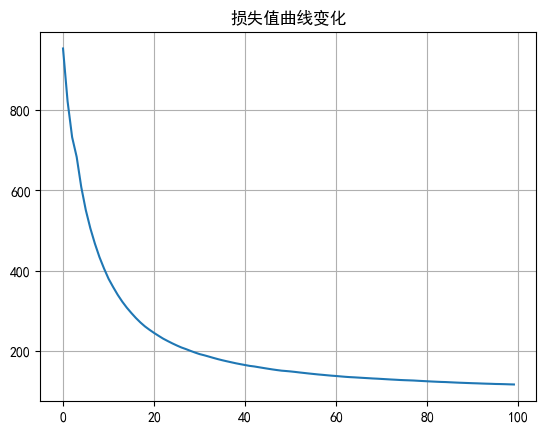

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5864\1028894505.py:60: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  y_pred=torch.tensor(data=[[v*model.weight+model.bias]for v in x])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5864\1028894505.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true=torch.tensor(data=[v*coef+14.5 for v in x])


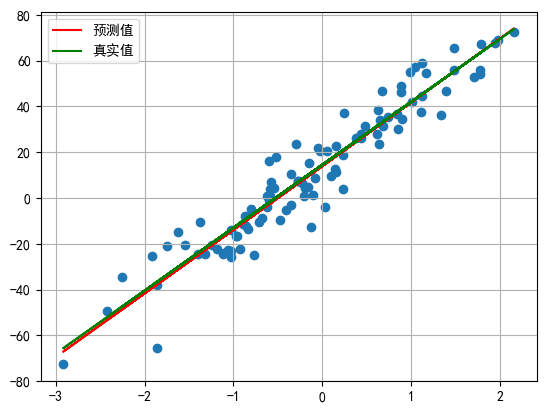

In [8]:
# 2.定义函数，表示模型训练
def train(x,y,coef):
    # 1.创建数据集对象，把tensor ——> 数据集对象 ——> 数据加载器
    dataset=TensorDataset(x,y)

    # 2.创建数据加载器对象
    # 参1: 数据集对象, 参2: 批次大小, 参3: 是否打乱数据(训练集打乱, 测试集不打乱)
    dataloader=DataLoader(dataset,batch_size=16,shuffle=True)

    # 3.创建初始的线性回归模型
    # 参1: 输入特征维度, 参2: 输出特征维度
    model=nn.Linear(1,1)

    # 4.创建损失函数对象.
    criterion=nn.MSELoss()
    # 5.创建优化器对象
    # 参1: 模型参数, 参2: 学习率
    optimizer=optim.SGD(model.parameters(),lr=0.01)

    # 6.具体的训练过程
    # 6.1 定义变量, 分别表示: 训练轮数, 每轮的(平均)损失值, 训练总损失值, 训练的样本数.
    epochs,loss_list,total_loss,total_sample=100,[],0.0,0

    # 6.2 开始训练, 按轮训练.
    for epoch in range(epochs):
        # 6.3 每轮是分 批次 训练的, 所以从 数据加载器中 获取 批次数据.
        for train_x,train_y in dataloader:       # 7批(16, 16, 16, 16, 16, 16, 4)
            # 6.4 模型预测
            y_pred=model(train_x)
            # 6.5 计算损失
            loss=criterion(y_pred,train_y.reshape(-1,1))   # -1 自动计算.
            # 6.6 计算总损失 和 样本(批次)数
            total_loss+=loss.item()
            total_sample+=1

            # 6.7 梯度清零 + 反向传播 + 梯度更新
            optimizer.zero_grad()     # 梯度清零
            loss.backward()     # 反向传播, 计算梯度
            optimizer.step()    # 梯度更新

        # 6.8 把本轮的(平均)损失值，添加到列表中
        loss_list.append(total_loss/total_sample)
        print(f'轮数: {epoch + 1}, 平均损失值: {total_loss / total_sample}')

    # 7. 打印(最终的)训练结果.
    print(f'{epochs} 轮的平均损失分别为: {loss_list}')
    print(f'模型参数, 权重: {model.weight}, 偏置: {model.bias}')

    # 8.绘制损失曲线
    #                 100轮         每轮的平均损失值
    plt.plot(range(epochs),loss_list)
    plt.title('损失值曲线变化')
    plt.grid(True)
    plt.show()
    # 9.绘制预测值和真实值的关系
    # 9.1 绘制样本点分布情况
    plt.scatter(x,y)
     # 9.2 绘制训练模型的预测值.
    # x: 100个样本点的特征.
    y_pred=torch.tensor(data=[[v*model.weight+model.bias]for v in x])
    # 9.3 计算真实值
    y_true=torch.tensor(data=[v*coef+14.5 for v in x])
    # 9.4 绘制预测值 和 真实值的 折线图.
    plt.plot(x, y_pred, color='red', label='预测值')
    plt.plot(x, y_true, color='green', label='真实值')
    # 9.5 图例, 网格.
    plt.legend()
    plt.grid()
    # 9.6 显示图像.
    plt.show()
train(x, y, coef)